# CelebA-HQ (P2): sample grids

Two grids of generated faces with P2 on CelebA-HQ, guided by Debias Anything through
`scripts/p2/generate.py`. Every grid shares six starting noises across its rows: image $i$ of each
row starts from a CPU generator seeded with `seed + i` (`per_sample_noise_seeds=true`), so a column is
one noise under several regimes. P2 sampling is deterministic on GPU. Figures are written to
`outputs/figures/p2/`.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
P2 = ROOT / "checkpoints/celebahq_p2.pt"
ADAPTER = ROOT / "checkpoints/celebahq_p2_adapter.pt"
OUT = ROOT / "outputs/figures/p2"
N, STEPS, ETA = 6, 50, 1


def debias_anything(name, seed, source, target, proportion, weight, *extra):
    out = OUT / f"{name}_seed{seed}"
    # Hydra overrides; the prompts are quoted, since some contain an apostrophe
    subprocess.run(
        [
            sys.executable,
            str(ROOT / "scripts/p2/generate.py"),
            f"p2_checkpoint={P2}",
            f"projector_checkpoint={ADAPTER}",
            f'source_prompt="{source}"',
            f'target_prompt="{target}"',
            f"target_proportion={proportion}",
            f"guidance_weight={weight}",
            f"n_images={N}",
            f"batch_size={N}",
            f"n_ddim_steps={STEPS}",
            f"eta={ETA}",
            f"seed={seed}",
            "per_sample_noise_seeds=true",
            f"out={out}",
            f"hydra.run.dir={out}/hydra",
            *extra,
        ],
        cwd=ROOT,
        check=True,
    )
    return [out / f"{i:05d}.png" for i in range(N)]


def unguided(seed):
    # generate.py at w = 0. The unguided rows of the paper were saved by the code of Balancing Act,
    # which rounds to the nearest grey level where generate.py truncates: same samples up to one
    # grey level.
    return debias_anything(
        "unguided", seed, "a photo of a woman", "a photo of a man", 0.5, 0
    )


def grid(rows, name):
    plt.rcParams.update({"font.family": "serif", "font.size": 14, "pdf.fonttype": 42})
    fig, axes = plt.subplots(
        len(rows),
        N,
        figsize=(2 * N, 2 * len(rows)),
        squeeze=False,
        gridspec_kw=dict(wspace=0.02, hspace=0.02),
    )
    for axes_row, (label, paths) in zip(axes, rows.items()):
        axes_row[0].set_ylabel(label, labelpad=6)
        for ax, path in zip(axes_row, paths):
            ax.imshow(Image.open(path), interpolation="none")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines[:].set_visible(False)
    # the PDF embeds the 256 px images as they are; the PNG is at twice their native resolution
    fig.savefig(OUT / f"{name}.pdf", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(OUT / f"{name}.png", bbox_inches="tight", pad_inches=0.02, dpi=256)
    plt.show()

## Fairness and diversity terms on gender

Seed 45: the unguided model, the fairness term alone ($w_{fair} = 20$, target one half,
*a photo of a woman* / *a photo of a man*), and the fairness term with the PerturbProj diversity
term ($w_{div} = 80$, re-noising at $\sigma_s = 0.5\,\sigma$, at every step).

[2026-09-30 08:48:14,947][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:48:14,948][huggingface_hub.utils._http][WARNING] - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
[2026-09-30 08:48:14,955][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json "HTTP/1.1 200 OK"


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 4292.30it/s]


[2026-09-30 08:48:16,246][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:48:16,475][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:48:16,484][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[2026-09-30 08:48:16,719][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:48:16,950][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:48:16,956][httpx][INFO] - HTTP Reques

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 4293.65it/s]


[2026-09-30 08:48:40,472][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:48:40,707][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:48:40,715][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[2026-09-30 08:48:40,948][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:48:41,182][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:48:41,191][httpx][INFO] - HTTP Reques

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 5184.07it/s]


[2026-09-30 08:49:06,572][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:49:06,807][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:49:06,814][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[2026-09-30 08:49:07,048][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:49:07,284][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:49:07,292][httpx][INFO] - HTTP Reques

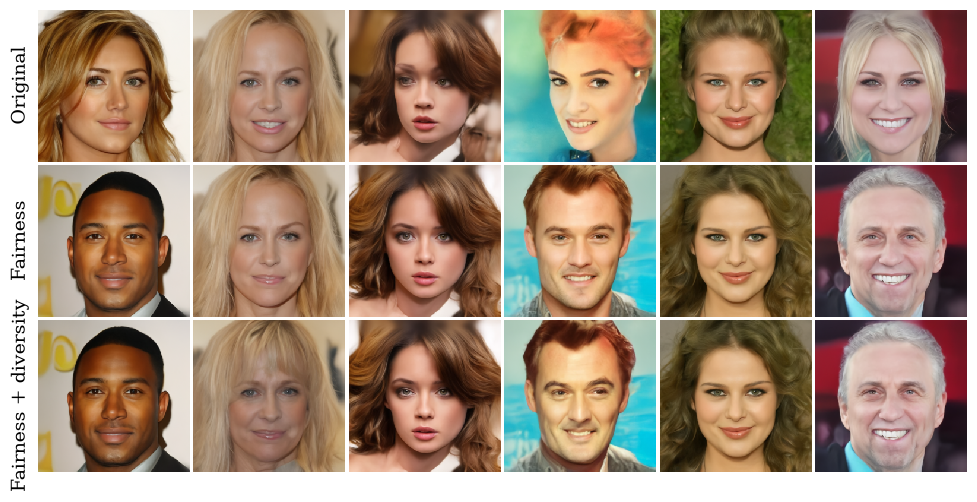

In [2]:
SEED = 45
PAIR = ("a photo of a woman", "a photo of a man")
grid(
    {
        "Original": unguided(SEED),
        "Fairness": debias_anything("gender_fairness", SEED, *PAIR, 0.5, 20),
        "Fairness + diversity": debias_anything(
            "gender_fairness_diversity",
            SEED,
            *PAIR,
            0.5,
            20,
            "perturb_proj=true",
            "perturb_proj_weight=80",
        ),
    },
    "gender_fairness_diversity",
)

## Choice of the sentences

Gender, seed 123, $w_{fair} = 20$, target one half: the unguided model, then one pair of sentences
describing the attribute per row.

[2026-09-30 08:49:36,891][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:49:36,899][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json "HTTP/1.1 200 OK"


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 4162.93it/s]


[2026-09-30 08:49:38,195][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:49:38,196][huggingface_hub.utils._http][WARNING] - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


[2026-09-30 08:49:38,431][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:49:38,439][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[2026-09-30 08:49:38,669][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:49:38,904][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:49:38,910][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[20

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 3606.40it/s]


...

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 3881.47it/s]


[2026-09-30 08:51:22,085][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:51:22,326][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:51:22,327][huggingface_hub.utils._http][WARNING] - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
[2026-09-30 08:51:22,340][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"


[2026-09-30 08:51:22,596][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:51:22,827][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:51:22,833][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[2026-09-30 08:51:23,069][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/models/google/siglip2-base-patch16-224/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
[2026-09-30 08:51:23,306][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:51:23,537

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 4845.30it/s]


[2026-09-30 08:51:48,505][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:51:48,739][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:51:48,746][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/preprocessor_config.json "HTTP/1.1 200 OK"
[2026-09-30 08:51:48,977][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
[2026-09-30 08:51:49,209][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-09-30 08:51:49,215][httpx][INFO] - HTTP Reques

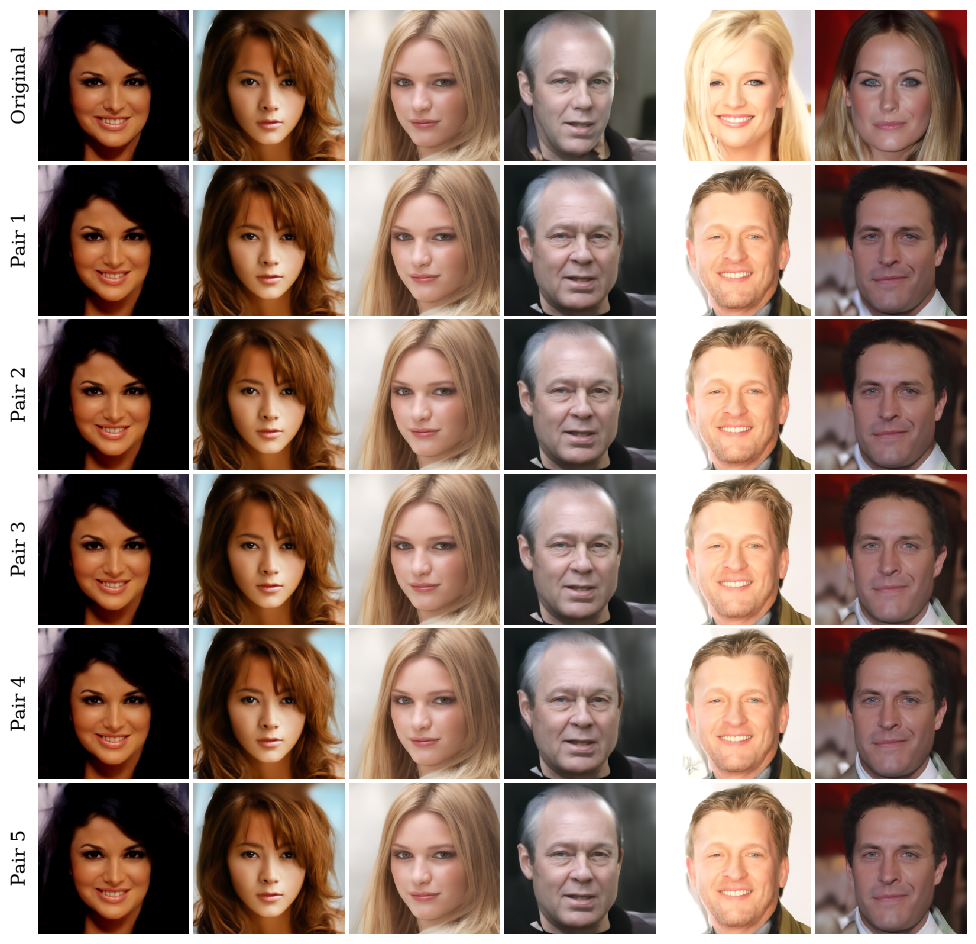

In [3]:
SEED = 123
PAIRS = [
    ("a photo of a woman", "a photo of a man"),
    ("a female person", "a male person"),
    ("a girl's portrait", "a boy's portrait"),
    ("a photo of a lady", "a photo of a gentleman"),
    ("a woman's close-up photo", "a man's close-up photo"),
]
rows = {"Original": unguided(SEED)}
for k, (source, target) in enumerate(PAIRS, 1):
    rows[f"Pair {k}"] = debias_anything(
        f"gender_pair{k}", SEED, source, target, 0.5, 20
    )
grid(rows, "gender_sentence_pairs")